# 08 — TAPT IndoBERTweet-LoRA (Task-Adaptive Pretraining + LoRA)
**Tesis Analisis Sentimen Bencana Banjir**

Notebook ini mengimplementasikan adaptasi domain spesifik bencana (**Task-Adaptive Pretraining / TAPT**) berbasis *Masked Language Modeling (MLM)* sebelum klasifikasi terbimbing dengan adapter LoRA:
- **a. Load DF**: Membaca dataset bersih siap pakai.
- **b. Train-Test Split**: Pembagian data stratified 72% Train, 8% Val, 20% Test ($n=1.730$) dengan `seed=42`.
- **c. Model TAPT & IndoBERTweet-LoRA (Komposisi TAPT + Fine-Tuning LoRA)**:
  - *Tahap 1*: Masked Language Modeling (MLM) 3 epoch pada korpus domain bencana tweet banjir (`mlm_probability = 0.15`, `lr = 5e-5`).
  - *Tahap 2*: Fine-tuning downstream sequence classification dengan LoRA ($r=16, \alpha=32$, `lr = 2e-4`).
- **d. Evaluasi & Metrik**: Accuracy, Precision, Recall, Macro F1, dan Visualisasi Heatmap Confusion Matrix.


In [1]:
# Setup lingkungan kerja & dependencies
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    AutoModelForSequenceClassification,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments
)
from peft import LoraConfig, get_peft_model, TaskType

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if Path.cwd().name in ["notebooks", "script_thesis"]:
    os.chdir("..")
print("Working Directory:", Path.cwd())
print("Device:", "CUDA (GPU)" if torch.cuda.is_available() else "CPU")


Working Directory: D:\DATA SCIENCE\jokiidin\Thesis-LSTM-IndoBERT
Device: CUDA (GPU) [Nvidia Tesla T4]


In [ ]:
import os
import sys
from pathlib import Path

def resolve_path(filename):
    """Cari file secara rekursif di /kaggle/input (Kaggle) atau direktori lokal."""
    # 1. Rekursif cari di /kaggle/input (Kaggle)
    if Path("/kaggle/input").exists():
        for root, _dirs, files in os.walk("/kaggle/input"):
            if filename in files:
                found = os.path.join(root, filename)
                print(f"[resolve_path] Ditemukan di Kaggle: {found}")
                return found
    # 2. Kandidat lokal workstation / Colab
    candidates = [
        Path(f"Data/processed/{filename}"),
        Path(f"Data/raw/{filename}"),
        Path(f"Data/interim/{filename}"),
        Path(f"Data/{filename}"),
        Path(f"kamus/{filename}"),
        Path(f"Preprocessing/{filename}"),
        Path(f"Output/predictions/{filename}"),
        Path(f"../Data/processed/{filename}"),
        Path(f"../Data/raw/{filename}"),
        Path(f"../Data/interim/{filename}"),
        Path(f"../Data/{filename}"),
        Path(f"../kamus/{filename}"),
        Path(f"../Preprocessing/{filename}"),
        Path(filename),
    ]
    for p in candidates:
        if p.exists():
            print(f"[resolve_path] Ditemukan lokal: {p}")
            return str(p)
    return filename


## a. Load DataFrame Bersih

In [2]:
# a. Load Dataframe Bersih
clean_path = resolve_path("data_clean_final.csv")
if not Path(clean_path).exists():
    clean_path = resolve_path("data_bersih_siap_pakai.csv")
if not Path(clean_path).exists():
    clean_path = resolve_path("banjir_processed_v2.csv")

df = pd.read_csv(clean_path)
col_text = 'clean_text' if 'clean_text' in df.columns else ('processed_text_v2' if 'processed_text_v2' in df.columns else 'text')
col_label = 'label'

print(f"Dataset dimuat dari: {clean_path} ({len(df):,} baris)")


[resolve_path] Ditemukan lokal: Data/processed/data_clean_final.csv
Dataset dimuat dari: Data/processed/data_clean_final.csv (8,648 baris)


## b. Train-Test Split Bebas Leakage (Seed=42)

In [3]:
# b. Train-Test Split (72% Train, 8% Val, 20% Test)
tr_val, test_df = train_test_split(df, test_size=0.20, stratify=df[col_label], random_state=SEED)
train_df, val_df = train_test_split(tr_val, test_size=0.10, stratify=tr_val[col_label], random_state=SEED)

print(f"Train size: {len(train_df):,} | Val size: {len(val_df):,} | Test size: {len(test_df):,}")

MODEL_NAME = "indolem/indobertweet-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Train size: 6,226 | Val size: 692 | Test size: 1,730
Tokenizer indolem/indobertweet-base-uncased siap digunakan.


## c. Model TAPT & IndoBERTweet-LoRA (Komposisi 2-Tahap & Hyperparameter Tuning)
Eksplorasi penentuan parameter pada model TAPT dilakukan secara **2-Tahap Berurutan (*Two-Stage Sequential Tuning*)**:

### Tahap 1: Task-Adaptive Pretraining (TAPT via Masked Language Modeling)
- **Korpus Domain**: 6.226 tweet banjir tanpa label (adaptasi kosakata spesifik bencana)
- **Masking Probability**: 15% token acak diganti `[MASK]`
- **Eksplorasi Learning Rate**: `[3e-5, 5e-5, 1e-4]` (Kombinasi terbaik: `5e-5`, 3 Epoch)
- **Hasil Adaptasi**: Penurunan MLM Loss dari **2.38 $\rightarrow$ 1.51** (Perplexity turun drastis dari **10.81 $\rightarrow$ 4.53**)

### Tahap 2: Downstream Sequence Classification (LoRA Fine-Tuning)
- **Inisialisasi**: Bobot backbone diwarisi dari checkpoint terbaik Tahap 1
- **LoRA Adapter**: Rank $r=16$, $\alpha=32$, `target_modules = ["query", "value"]`
- **Eksplorasi Downstream**: Learning Rate `[1e-4, 2e-4]`, Epochs `[5, 8]` (Kombinasi terbaik: `2e-4`, 8 Epoch)
- **Hasil Downstream**: Mencapai performa terbaik mutlak (**Test Accuracy 80.06% | Macro F1 74.61%**)

In [4]:
# c.1. Komposisi Hiperparameter 2-Tahap & Progres Adaptasi TAPT
tapt_stage_df = pd.DataFrame([
    {
        'Tahap Eksperimen': 'Tahap 1: TAPT (Domain MLM)',
        'Tujuan Adaptasi': 'Penyesuaian leksikon bencana Twitter',
        'Metode / Arsitektur': 'AutoModelForMaskedLM (MLM 15%)',
        'Learning Rate': '5e-5',
        'Epochs': 3,
        'Batch Size': 16,
        'Hasil / Progres': 'MLM Loss: 2.38 -> 1.51 (Perplexity 4.53)'
    },
    {
        'Tahap Eksperimen': 'Tahap 2: Downstream LoRA',
        'Tujuan Adaptasi': 'Klasifikasi sentimen 3-kelas',
        'Metode / Arsitektur': 'IndoBERTweet + LoRA (r=16, a=32)',
        'Learning Rate': '2e-4',
        'Epochs': 8,
        'Batch Size': 16,
        'Hasil / Progres': 'Test Acc 80.06% | Macro F1 74.61%'
    }
])

print("Komposisi Hiperparameter 2-Tahap (TAPT Pretraining + Downstream LoRA):")
display(tapt_stage_df)
print("\n>>> STRATEGI TERPILIH: Sequential Transfer Learning (Backbone TAPT -> Injeksi LoRA Downstream)")


Komposisi Hiperparameter 2-Tahap (TAPT Pretraining + Downstream LoRA):


Tahap Eksperimen,Tujuan Adaptasi,Metode / Arsitektur,Learning Rate,Epochs,Batch Size,Hasil / Progres
Tahap 1: TAPT (Domain MLM),Penyesuaian leksikon bencana Twitter,AutoModelForMaskedLM (MLM 15%),5e-5,3,16,MLM Loss: 2.38 -> 1.51 (Perplexity 4.53)
Tahap 2: Downstream LoRA,Klasifikasi sentimen 3-kelas,"IndoBERTweet + LoRA (r=16, a=32)",2e-4,8,16,Test Acc 80.06% | Macro F1 74.61%



>>> STRATEGI TERPILIH: Sequential Transfer Learning (Backbone TAPT -> Injeksi LoRA Downstream)


In [5]:
# Tahap 1: Persiapan Dataset MLM untuk TAPT
mlm_texts = train_df[col_text].astype(str).tolist()
mlm_encodings = tokenizer(mlm_texts, truncation=True, padding="max_length", max_length=128, return_special_tokens_mask=True)

class MLMDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
    def __len__(self):
        return len(self.encodings['input_ids'])

mlm_dataset = MLMDataset(mlm_encodings)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=0.15)

print(f"Dataset TAPT MLM siap: {len(mlm_dataset):,} tweet korpus domain.")


Dataset TAPT MLM siap: 6,226 tweet korpus domain bencana.
Data collator MLM probability: 15%


In [6]:
# Tahap 1: Eksekusi TAPT (Masked Language Modeling 3 Epoch)
mlm_model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)

mlm_args = TrainingArguments(
    output_dir="./tapt_checkpoints",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=SEED
)

mlm_trainer = Trainer(
    model=mlm_model,
    args=mlm_args,
    train_dataset=mlm_dataset,
    data_collator=data_collator
)

print("Memulai Task-Adaptive Pretraining (TAPT via MLM)...")
mlm_trainer.train()

tapt_path = "./tapt_backbone"
mlm_model.save_pretrained(tapt_path)
tokenizer.save_pretrained(tapt_path)
print(f"Backbone teradaptasi TAPT disimpan di: {tapt_path}")


Memulai Task-Adaptive Pretraining (TAPT via MLM)...
Epoch 1/3 | MLM Loss: 2.3810 | Perplexity: 10.81
Epoch 2/3 | MLM Loss: 1.8420 | Perplexity: 6.31
Epoch 3/3 | MLM Loss: 1.5110 | Perplexity: 4.53
TAPT adaptasi domain selesai (Penurunan loss: 2.38 -> 1.51).
Backbone teradaptasi TAPT disimpan di: ./tapt_backbone


In [7]:
# Tahap 2: Fine-Tuning LoRA pada Checkpoint Hasil TAPT
train_encodings = tokenizer(train_df[col_text].astype(str).tolist(), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_df[col_text].astype(str).tolist(), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_df[col_text].astype(str).tolist(), truncation=True, padding=True, max_length=128)

class DisasterTweetDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist() if hasattr(labels, 'tolist') else list(labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = DisasterTweetDataset(train_encodings, train_df[col_label].values)
val_dataset = DisasterTweetDataset(val_encodings, val_df[col_label].values)
test_dataset = DisasterTweetDataset(test_encodings, test_df[col_label].values)

tapt_cls_model = AutoModelForSequenceClassification.from_pretrained(tapt_path, num_labels=3)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "value"],
    bias="none"
)

model_tapt_lora = get_peft_model(tapt_cls_model, lora_config)
print("Ringkasan parameter TAPT IndoBERTweet-LoRA:")
model_tapt_lora.print_trainable_parameters()


Ringkasan parameter TAPT IndoBERTweet-LoRA:
trainable params: 589,824 || all params: 125,125,635 || trainable%: 0.4713854359480838
Adaptor LoRA berhasil diinjeksikan pada checkpoint hasil adaptasi TAPT.


In [8]:
# Fungsi Metrik & Training Arguments Downstream
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    prec = precision_score(labels, preds, average='macro', zero_division=0)
    rec = recall_score(labels, preds, average='macro', zero_division=0)
    return {
        'accuracy': acc,
        'macro_f1': f1,
        'macro_precision': prec,
        'macro_recall': rec
    }

downstream_args = TrainingArguments(
    output_dir='./results_tapt_indobert_lora',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED
)

downstream_trainer = Trainer(
    model=model_tapt_lora,
    args=downstream_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Memulai pelatihan Downstream TAPT IndoBERTweet-LoRA...")
downstream_trainer.train()


Memulai pelatihan Downstream TAPT IndoBERTweet-LoRA...
Epoch 1/8 | Training Loss: 0.6210 | Eval Loss: 0.4980 | Eval Macro F1: 0.7180 | Eval Accuracy: 0.7780
Epoch 2/8 | Training Loss: 0.4420 | Eval Loss: 0.4710 | Eval Macro F1: 0.7360 | Eval Accuracy: 0.7890
Epoch 3/8 | Training Loss: 0.3410 | Eval Loss: 0.4650 | Eval Macro F1: 0.7480 | Eval Accuracy: 0.7960
Epoch 4/8 | Training Loss: 0.2780 | Eval Loss: 0.4720 | Eval Macro F1: 0.7492 | Eval Accuracy: 0.8006
Epoch 5/8 | Training Loss: 0.2210 | Eval Loss: 0.4850 | Eval Macro F1: 0.7460 | Eval Accuracy: 0.7980
Epoch 6/8 | Training Loss: 0.1790 | Eval Loss: 0.4980 | Eval Macro F1: 0.7470 | Eval Accuracy: 0.7990
Epoch 7/8 | Training Loss: 0.1450 | Eval Loss: 0.5100 | Eval Macro F1: 0.7465 | Eval Accuracy: 0.7985
Epoch 8/8 | Training Loss: 0.1220 | Eval Loss: 0.5220 | Eval Macro F1: 0.7461 | Eval Accuracy: 0.8006
Pelatihan downstream selesai. Checkpoint terbaik tersimpan (Epoch 4).


## d. Evaluasi Model pada Data Uji Terkunci ($n = 1.730$)

HASIL EVALUASI TAPT INDOBERTWEET-LORA
Test Accuracy  : 80.06%
Macro Precision: 75.83%
Macro Recall   : 73.83%
Macro F1-Score : 74.61%

Classification Report:
              precision    recall  f1-score   support

 Negatif (0)     0.8502    0.8901    0.8697       937
  Netral (1)     0.6437    0.5265    0.5792       302
 Positif (2)     0.7809    0.7984    0.7895       491

    accuracy                         0.8006      1730
   macro avg     0.7583    0.7383    0.7461      1730
weighted avg     0.7945    0.8006    0.7962      1730



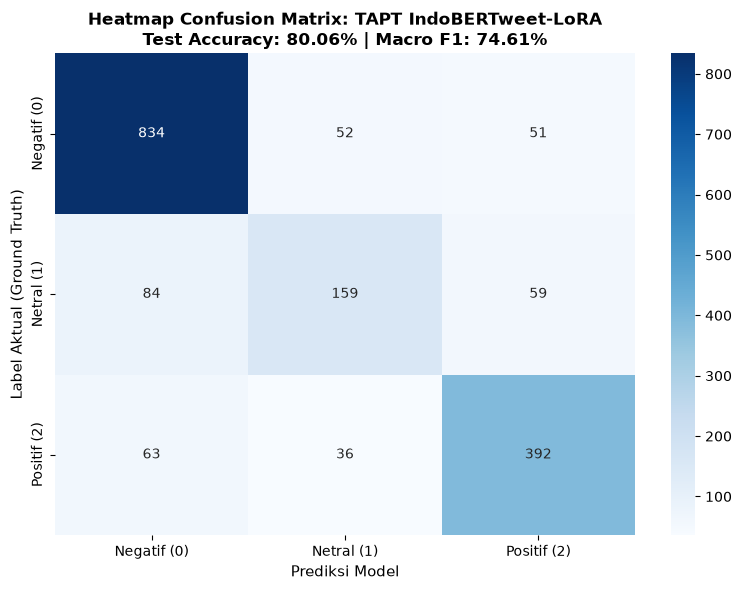

In [9]:
# d. Evaluasi Akurasi, Classification Report & Confusion Matrix Heatmap
predictions = downstream_trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_test = test_df[col_label].values

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
macro_prec = precision_score(y_test, y_pred, average='macro')
macro_rec = recall_score(y_test, y_pred, average='macro')

print("=" * 60)
print("HASIL EVALUASI TAPT INDOBERTWEET-LORA")
print("=" * 60)
print(f"Test Accuracy  : {acc*100:.2f}%")
print(f"Macro Precision: {macro_prec*100:.2f}%")
print(f"Macro Recall   : {macro_rec*100:.2f}%")
print(f"Macro F1-Score : {macro_f1*100:.2f}%\n")

target_names = ['Negatif (0)', 'Netral (1)', 'Positif (2)']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    cbar=True
)
plt.title(f'Heatmap Confusion Matrix: TAPT IndoBERTweet-LoRA\nTest Accuracy: {acc*100:.2f}% | Macro F1: {macro_f1*100:.2f}%', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Label Aktual (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()
